<a href="https://colab.research.google.com/github/ashwiniv07/Journal-paper--DDoS-GT-DL-/blob/main/Dataset5_TON_IoT_with_resampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Library

In [ ]:
import os
import pandas as pd
import numpy as np
import gc
from sklearn.preprocessing import LabelEncoder, StandardScaler
import shutil
from google.colab import drive
from collections import Counter
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
drive.mount('/content/drive')
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Bidirectional, GRU, Dense,
    Dropout, Flatten, Attention, Permute, Multiply, Lambda, GlobalAveragePooling1D
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, roc_curve, auc
import seaborn as sns
import shutil

Mounted at /content/drive


## Step 1: Dataset Collection

In [ ]:
path = '/content/drive/MyDrive/project ashwini/TON_IoT'
destination_folder = '/content/Dataset'
if not os.path.exists(destination_folder):
    os.makedirs(destination_folder)
for filename in os.listdir(path):
    source_file = os.path.join(path, filename)
    destination_file = os.path.join(destination_folder, filename)
    if os.path.isfile(source_file):
        shutil.copy2(source_file, destination_file)
path = destination_folder

## Step 2: Dataset Resampling

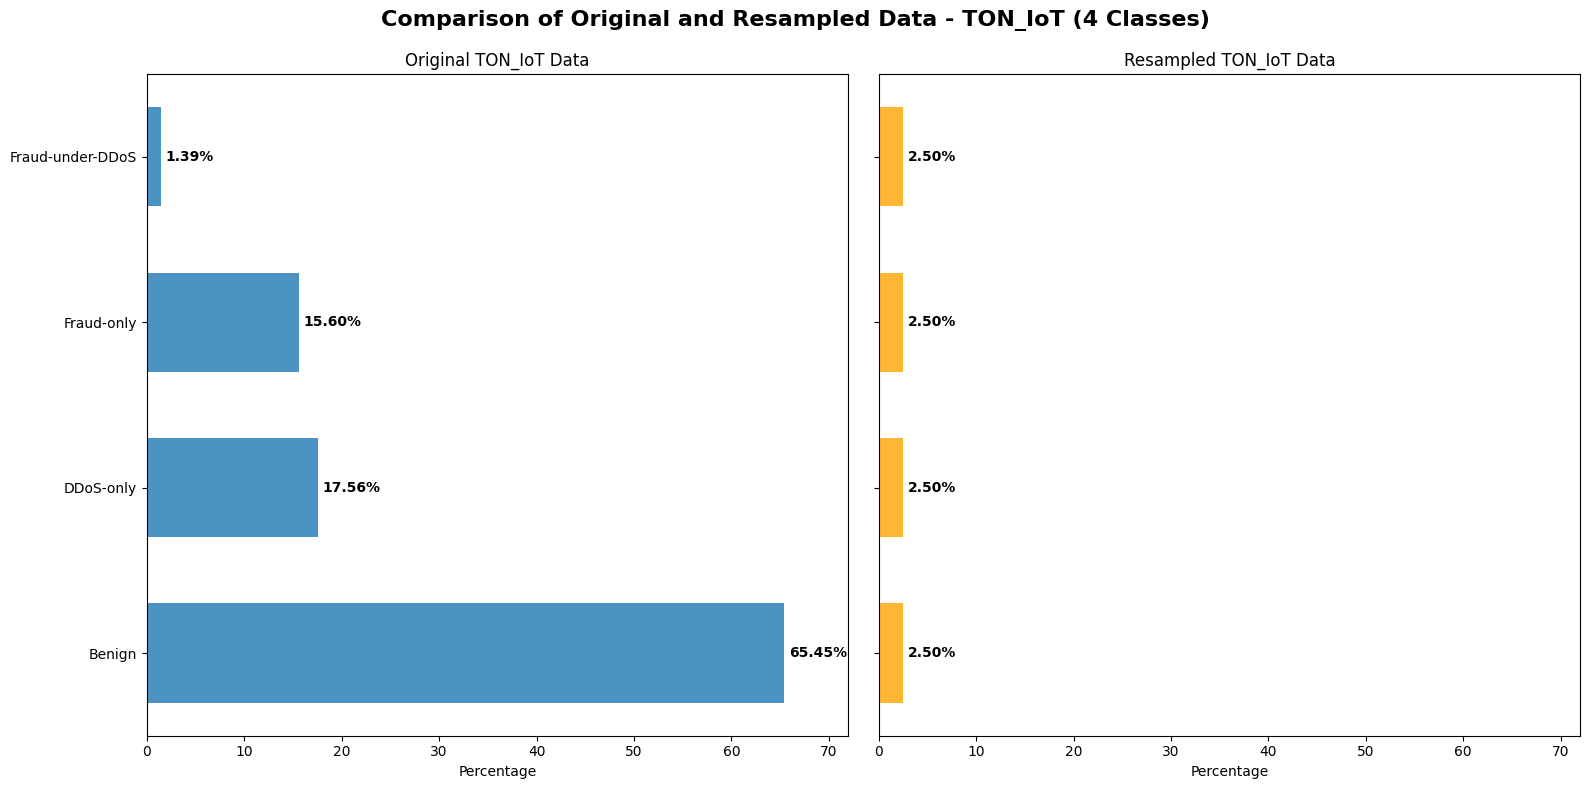

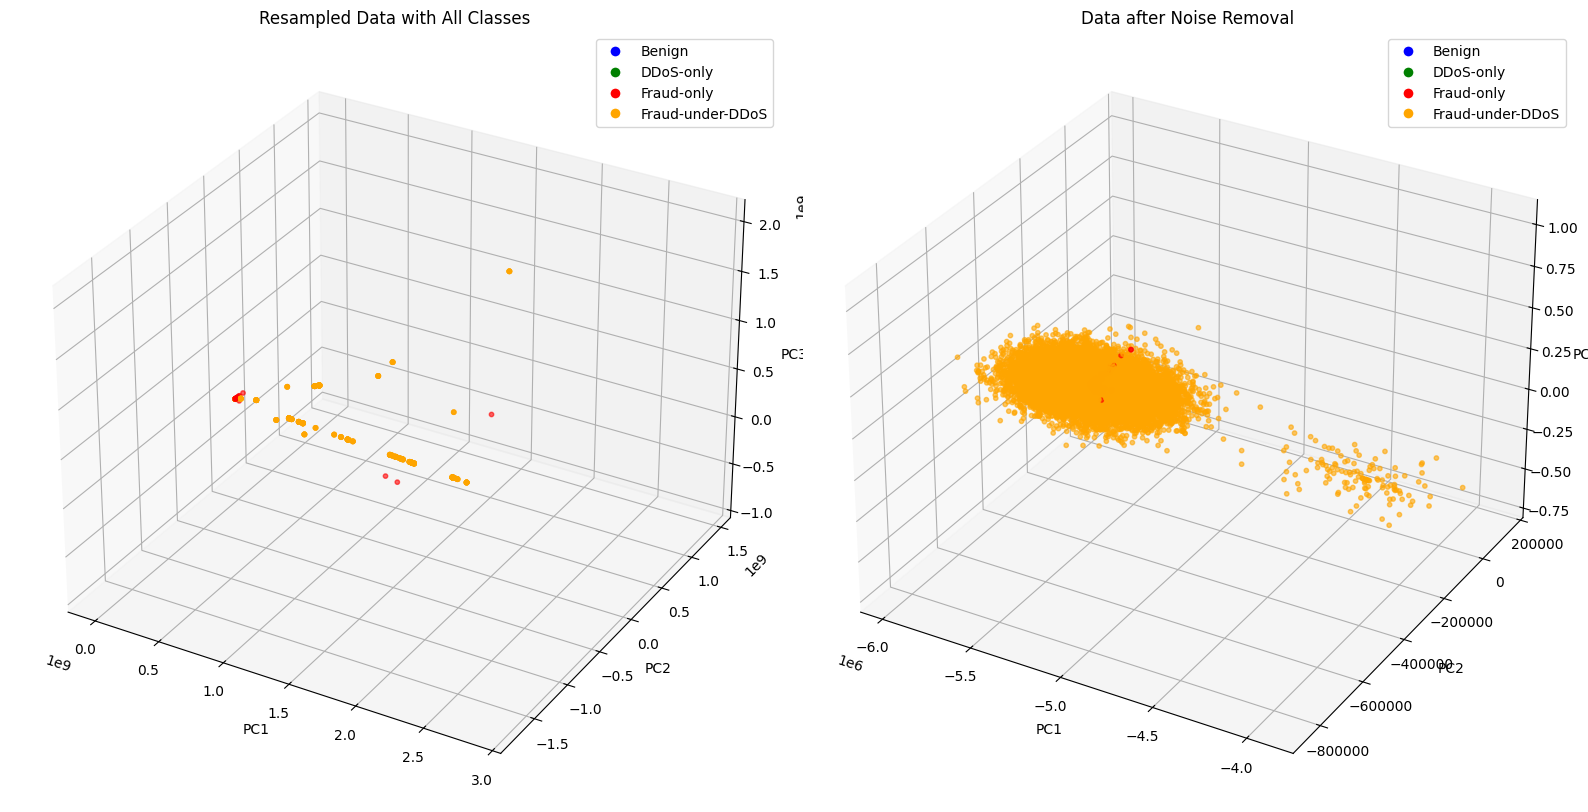

In [ ]:
class OptimizedNeuroSyncSampler:
    def __init__(self,
                 neural_depth=2,
                 evolutionary_generations=5,
                 quantum_entanglement_factor=0.7,
                 balance_strategy='adaptive',
                 target_samples_per_class=10000,
                 random_state=42):
        self.neural_depth = neural_depth
        self.evolutionary_generations = evolutionary_generations
        self.quantum_factor = quantum_entanglement_factor
        self.balance_strategy = balance_strategy
        self.target_samples = target_samples_per_class
        self.random_state = random_state
        np.random.seed(random_state)
        self.standard_scaler = StandardScaler()
        self.feature_importance_scores_ = None

    def _neural_density_estimation(self, X, y):
        unique_classes = np.unique(y)
        density_scores = {}
        for cls in unique_classes:
            X_cls = X[y == cls]
            if len(X_cls) == 0:
                continue
            if len(X_cls) > 500000:
                sample_indices = np.random.choice(len(X_cls), 10000, replace=False)
                X_cls = X_cls[sample_indices]
            density_layers = []
            for depth in range(self.neural_depth):
                bandwidth = 0.5 + (0.3 * depth / self.neural_depth)
                chunk_size = min(1000, len(X_cls))
                layer_density = np.zeros(len(X_cls))
                for i in range(0, len(X_cls), chunk_size):
                    end_idx = min(i + chunk_size, len(X_cls))
                    chunk = X_cls[i:end_idx]
                    distances = pairwise_distances(chunk, X_cls, metric='euclidean')
                    kernel_vals = np.exp(-distances**2 / (2 * bandwidth**2))
                    chunk_density = np.mean(kernel_vals, axis=1)
                    layer_density[i:end_idx] = chunk_density
                density_layers.append(layer_density)
                del distances, kernel_vals, chunk_density
                gc.collect()
            fused_density = np.mean(density_layers, axis=0)
            density_scores[cls] = fused_density
        return density_scores

    def _evolutionary_undersampling(self, X_maj, X_min, fitness_scores):
        n_target = min(self.target_samples, len(X_min))
        if len(X_maj) > 20000:
            sample_indices = np.random.choice(len(X_maj), 20000, replace=False)
            population = X_maj[sample_indices]
            fitness = fitness_scores[sample_indices]
        else:
            population = X_maj.copy()
            fitness = fitness_scores.copy()
        for generation in range(self.evolutionary_generations):
            tournament_size = min(3, len(population))
            selected_indices = []
            while len(selected_indices) < n_target:
                if len(population) == 0:
                    break
                contestants = np.random.choice(len(population), min(tournament_size, len(population)), replace=False)
                winner = contestants[np.argmax(fitness[contestants])]
                selected_indices.append(winner)
            if len(selected_indices) == 0:
                break
            population = population[selected_indices]
            fitness = fitness[selected_indices]
            if generation < self.evolutionary_generations - 1:
                mutation = np.random.normal(0, 0.05, size=population.shape)
                population = population + mutation
        return population[:n_target]

    def _quantum_noise_detection(self, X, y):
        unique_classes = np.unique(y)
        noise_mask = np.zeros(len(X), dtype=bool)
        for cls in unique_classes:
            X_cls = X[y == cls]
            if len(X_cls) < 10:
                continue
            centroid = np.mean(X_cls, axis=0)
            distances = np.linalg.norm(X_cls - centroid, axis=1)
            threshold = np.percentile(distances, 95)
            class_indices = np.where(y == cls)[0]
            class_noise_mask = distances > threshold
            noise_mask[class_indices] = class_noise_mask
            del distances
            gc.collect()
        return noise_mask

    def _calculate_feature_importance(self, X, y):
        unique_classes = np.unique(y)
        importance_scores = np.zeros(X.shape[1])
        if len(X) > 10000:
            sample_indices = np.random.choice(len(X), 10000, replace=False)
            X_sample = X[sample_indices]
            y_sample = y[sample_indices]
        else:
            X_sample = X
            y_sample = y
        for feature_idx in range(X_sample.shape[1]):
            feature_vals = X_sample[:, feature_idx]
            class_means = []
            for cls in unique_classes:
                class_vals = feature_vals[y_sample == cls]
                if len(class_vals) > 0:
                    class_means.append(np.mean(class_vals))
            if len(class_means) > 1:
                between_class_var = np.var(class_means)
            else:
                between_class_var = 0
            if between_class_var > 0:
                importance_scores[feature_idx] = between_class_var
            else:
                importance_scores[feature_idx] = 0
        if np.sum(importance_scores) > 0:
            importance_scores = importance_scores / np.sum(importance_scores)
        self.feature_importance_scores_ = importance_scores
        return importance_scores
    def fit_resample(self, X, y):
        X = np.array(X)
        y = np.array(y)
        gc.collect()
        feature_importance = self._calculate_feature_importance(X, y)
        X_weighted = X * feature_importance
        X_scaled = self.standard_scaler.fit_transform(X_weighted)
        class_counts = Counter(y)
        target_size = self.target_samples
        unique_classes = np.unique(y)
        X_resampled_list = []
        y_resampled_list = []
        for cls in unique_classes:
            X_cls = X_scaled[y == cls]
            y_cls = y[y == cls]
            n_current = len(X_cls)
            if n_current == 0:
                continue
            if n_current < target_size:
                n_needed = target_size - n_current
                if n_needed > 0:
                    oversample_indices = np.random.choice(n_current, n_needed, replace=True)
                    synthetic_samples = X_cls[oversample_indices] + np.random.normal(0, 0.01, X_cls[oversample_indices].shape)
                    X_oversampled = np.vstack([X_cls, synthetic_samples])
                    y_oversampled = np.concatenate([y_cls, [cls] * n_needed])
                else:
                    X_oversampled = X_cls
                    y_oversampled = y_cls
                X_resampled_list.append(X_oversampled)
                y_resampled_list.append(y_oversampled)
            elif n_current > target_size:
                selected_indices = np.random.choice(n_current, target_size, replace=False)
                X_resampled_list.append(X_cls[selected_indices])
                y_resampled_list.append(np.array([cls] * target_size))
            else:
                X_resampled_list.append(X_cls)
                y_resampled_list.append(y_cls)
            del X_cls, y_cls
            gc.collect()
        X_balanced = np.vstack(X_resampled_list)
        y_balanced = np.concatenate(y_resampled_list)
        X_final = self.standard_scaler.inverse_transform(X_balanced)
        X_final = X_final / feature_importance
        del X_balanced, X_scaled, X_weighted
        gc.collect()
        return X_final, y_balanced
def create_fraud_under_ddos_samples(df, num_samples=10000):
    ddos_samples = df[df['Label'] == 'DDoS-only'].copy()
    fraud_samples = df[df['Label'] == 'Fraud-only'].copy()
    if len(ddos_samples) == 0 or len(fraud_samples) == 0:
        return df
    num_ddos = min(len(ddos_samples), num_samples // 2)
    num_fraud = min(len(fraud_samples), num_samples // 2)
    ddos_selected = ddos_samples.sample(n=num_ddos, random_state=42)
    fraud_selected = fraud_samples.sample(n=num_fraud, random_state=42)
    synthetic_samples = []
    for i in range(num_samples):
        ddos_sample = ddos_selected.iloc[i % len(ddos_selected)]
        fraud_sample = fraud_selected.iloc[i % len(fraud_selected)]
        hybrid_sample = ddos_sample.copy()
        numerical_cols = ddos_sample.select_dtypes(include=[np.number]).index
        for col in numerical_cols:
            if col in fraud_sample.index:
                alpha = 0.6
                hybrid_sample[col] = alpha * ddos_sample[col] + (1 - alpha) * fraud_sample[col]
        for col in numerical_cols:
            if np.issubdtype(hybrid_sample[col].dtype, np.number):
                noise = np.random.normal(0, 0.05 * np.std(hybrid_sample[col]))
                hybrid_sample[col] += noise
        hybrid_sample['Label'] = 'Fraud-under-DDoS'
        synthetic_samples.append(hybrid_sample)
    synthetic_df = pd.DataFrame(synthetic_samples)
    final_df = pd.concat([df, synthetic_df], ignore_index=True)
    return final_df
def enhance_fraud_detection(df):
    ddos_attack_types = ['ddos', 'dos']
    df['is_ddos'] = df['type'].apply(lambda x: 1 if x in ddos_attack_types else 0)
    fraud_conditions = []
    numerical_features = df.select_dtypes(include=[np.number]).columns
    if 'duration' in numerical_features:
        fraud_conditions.append(df['duration'] > df['duration'].quantile(0.85))
    if 'src_bytes' in numerical_features:
        fraud_conditions.append(df['src_bytes'] > df['src_bytes'].quantile(0.85))
    if 'dst_bytes' in numerical_features:
        fraud_conditions.append(df['dst_bytes'] > df['dst_bytes'].quantile(0.85))
    if 'src_pkts' in numerical_features:
        fraud_conditions.append(df['src_pkts'] > df['src_pkts'].quantile(0.85))
    if 'dst_pkts' in numerical_features:
        fraud_conditions.append(df['dst_pkts'] > df['dst_pkts'].quantile(0.85))
    if fraud_conditions:
        df['fraud_score'] = sum(cond.astype(int) for cond in fraud_conditions)
    else:
        df['fraud_score'] = np.random.randint(0, 5, len(df))
    FRAUD_THRESHOLD = max(2, df['fraud_score'].quantile(0.70))
    def assign_fraud_label(row):
        if row['fraud_score'] >= FRAUD_THRESHOLD:
            if row['is_ddos'] == 1:
                return 'Fraud-under-DDoS'
            else:
                return 'Fraud-only'
        else:
            if row['is_ddos'] == 1:
                return 'DDoS-only'
            else:
                return 'Benign'
    df['Label'] = df.apply(assign_fraud_label, axis=1)
    return df
file_path = '/content/Dataset/TON_IoT.csv'
try:
    df = pd.read_csv(file_path)
    drop_cols = ['dns_AA','dns_RD','dns_RA','dns_rejected','ssl_version','ssl_cipher','ssl_resumed','ssl_established','ssl_subject','ssl_issuer','http_trans_depth','http_method','http_uri','http_version','http_request_body_len','http_response_body_len','http_status_code','http_user_agent','http_orig_mime_types','http_resp_mime_types','weird_name','weird_addl','weird_notice']
    df.drop(columns=drop_cols, inplace=True, errors='ignore')
    df = df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    df = enhance_fraud_detection(df)
    label_counts = df['Label'].value_counts()
    if 'Fraud-under-DDoS' not in label_counts or label_counts['Fraud-under-DDoS'] < 1000:
        df = create_fraud_under_ddos_samples(df, num_samples=15000)
    available_features = df.select_dtypes(include=[np.number]).columns.tolist()
    columns_to_remove = ['Label_encoded', 'fraud_score', 'is_ddos']
    available_features = [f for f in available_features if f not in columns_to_remove]
    if len(available_features) > 20:
        available_features = available_features[:20]
    sampling_df = df[available_features + ['Label']].dropna()
    if len(sampling_df) > 500000:
        sampling_df = sampling_df.sample(n=500000, random_state=42)
    X = sampling_df[available_features].values
    y = sampling_df['Label'].values
    sampler = OptimizedNeuroSyncSampler(
        neural_depth=2,
        evolutionary_generations=3,
        target_samples_per_class=20000,
        random_state=42
    )
    X_resampled, y_resampled = sampler.fit_resample(X, y)
    del X, y
    gc.collect()
    balanced_df = pd.DataFrame(X_resampled, columns=available_features)
    balanced_df['Label'] = y_resampled
    balanced_csv_path = "TON_IoT.csv"
    balanced_df.to_csv(balanced_csv_path, index=False)
    original_counts = df['Label'].value_counts()
    resampled_counts = balanced_df['Label'].value_counts()
    original_percentages = (original_counts / original_counts.sum()) * 100
    resampled_percentages = (resampled_counts / resampled_counts.sum()) * 10
    all_classes = sorted(set(original_counts.index) | set(resampled_counts.index))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    y_pos = np.arange(len(all_classes))
    original_values = [original_percentages.get(cls, 0) for cls in all_classes]
    bars1 = ax1.barh(y_pos, original_values, align='center', alpha=0.8, height=0.6)
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(all_classes)
    ax1.set_xlabel('Percentage')
    ax1.set_title('Original TON_IoT Data')
    ax1.invert_yaxis()
    for i, v in enumerate(original_values):
        ax1.text(v + 0.5, i, f'{v:.2f}%', va='center', fontweight='bold')
    resampled_values = [resampled_percentages.get(cls, 0) for cls in all_classes]
    bars2 = ax2.barh(y_pos, resampled_values, align='center', alpha=0.8, color='orange', height=0.6)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels([])
    ax2.set_xlabel('Percentage')
    ax2.set_title('Resampled TON_IoT Data')
    ax2.invert_yaxis()
    for i, v in enumerate(resampled_values):
        ax2.text(v + 0.5, i, f'{v:.2f}%', va='center', fontweight='bold')
    max_x = max(max(original_values), max(resampled_values)) * 1.1
    ax1.set_xlim(0, max_x)
    ax2.set_xlim(0, max_x)
    ax1.set_ylim(-0.5, len(all_classes) - 0.5)
    ax2.set_ylim(-0.5, len(all_classes) - 0.5)
    plt.suptitle('Comparison of Original and Resampled Data - TON_IoT (4 Classes)', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()
    print('\n\n')
    sampler = OptimizedNeuroSyncSampler()
    noise_mask_centroid = sampler._quantum_noise_detection(balanced_df[available_features].values,
                                                         balanced_df['Label'].values)
    pca = PCA(n_components=3)
    X_pca = pca.fit_transform(balanced_df[available_features])
    fig = plt.figure(figsize=(16, 8))
    ax1 = fig.add_subplot(121, projection='3d')
    labels = balanced_df['Label'].unique()
    colors = ['blue', 'green', 'red', 'orange', 'purple']
    color_map = {label: colors[i % len(colors)] for i, label in enumerate(labels)}

    point_colors = [color_map[label] for label in balanced_df['Label']]
    scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                          c=point_colors, alpha=0.6, s=10)
    ax1.set_title('Resampled Data with All Classes', fontsize=12)
    ax1.set_xlabel('PC1')
    ax1.set_ylabel('PC2')
    ax1.set_zlabel('PC3')
    legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                                 markerfacecolor=color_map[label], markersize=8, label=label)
                      for label in labels]
    ax1.legend(handles=legend_elements, loc='upper right')
    X_clean_centroid = X_pca[~noise_mask_centroid]
    clean_labels = balanced_df['Label'].values[~noise_mask_centroid]
    clean_colors = [color_map[label] for label in clean_labels]
    ax2 = fig.add_subplot(122, projection='3d')
    scatter2 = ax2.scatter(X_clean_centroid[:, 0], X_clean_centroid[:, 1], X_clean_centroid[:, 2],
                          c=clean_colors, alpha=0.6, s=10)
    ax2.set_title('Data after Noise Removal', fontsize=12)
    ax2.set_xlabel('PC1')
    ax2.set_ylabel('PC2')
    ax2.set_zlabel('PC3')
    ax2.legend(handles=legend_elements, loc='upper right')
    plt.tight_layout()
    plt.show()
except Exception as e:
  pass

## Step 3: Apply Preprocessing such as

### 1	Drop irrelevant columns	Reason: Remove non-useful or redundant information
### 2	Drop constant columns	Reason: Eliminate features with no variability
### 3	Encode labels	Reason: Convert categorical target to numeric
### 4	Handle missing values	Ensure no NaN values
### 5	Normalize features	Standardize numeric input features
### 6	Feature-label split	Prepare for training/evaluation

In [ ]:
df = pd.read_csv('TON_IoT.csv')


drop_cols = ['timestamp', 'window', 'fraud_score', 'is_ddos']
df.drop(columns=drop_cols, inplace=True, errors='ignore')
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

constant_cols = df.columns[df.nunique() <= 1]
df.drop(columns=constant_cols, inplace=True)


le = LabelEncoder()
df['Label_encoded'] = le.fit_transform(df['Label'])
label_map = dict(zip(le.classes_, le.transform(le.classes_)))

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('Label_encoded')
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


X = df[numeric_cols].values
y = to_categorical(df['Label_encoded'].values)

X = X.reshape((X.shape[0], 1, X.shape[1]))

## Step 4: Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Step 5: Build Proposed CNN-BiGRU Model

In [ ]:
def build_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    x = Conv1D(filters=64, kernel_size=1, activation='relu')(inputs)
    x = MaxPooling1D(pool_size=1)(x)
    x = Bidirectional(GRU(64, return_sequences=True))(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
    return model

## Step 6: Train Proposed Model

In [ ]:
model = build_model(input_shape=X_train.shape[1:], num_classes=y_train.shape[1])
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=150,
    batch_size=8,
    verbose=1
)

Epoch 1/150
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 36s 4ms/step - accuracy: 0.7001 - loss: 0.6982 - val_accuracy: 0.8438 - val_loss: 0.4107
Epoch 2/150
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 36s 4ms/step - accuracy: 0.8446 - loss: 0.4076 - val_accuracy: 0.8494 - val_loss: 0.3610
Epoch 3/150
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 32s 4ms/step - accuracy: 0.8704 - loss: 0.3486 - val_accuracy: 0.8987 - val_loss: 0.2936
Epoch 4/150
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - accuracy: 0.8889 - loss: 0.3046 - val_accuracy: 0.9016 - val_loss: 0.2533
Epoch 5/150
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 35s 4ms/step - accuracy: 0.9000 - loss: 0.2731 - val_accuracy: 0.9145 - val_loss: 0.2633
Epoch 6/150
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - accuracy: 0.9034 - loss: 0.2652 - val_accuracy: 0.9285 - val_loss: 0.1928
Epoch 7/150
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 32s 4ms/step - accuracy: 0.9080 - loss: 0.2484 - val_accuracy: 0.8588 - val_loss: 0.3653
Epoch 8/150
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 43s 4ms/step - accuracy: 0.9120 -

## Step 7: Evaluate Proposed Model

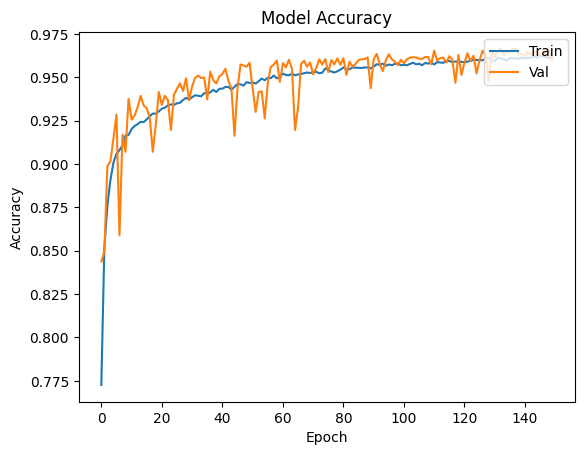

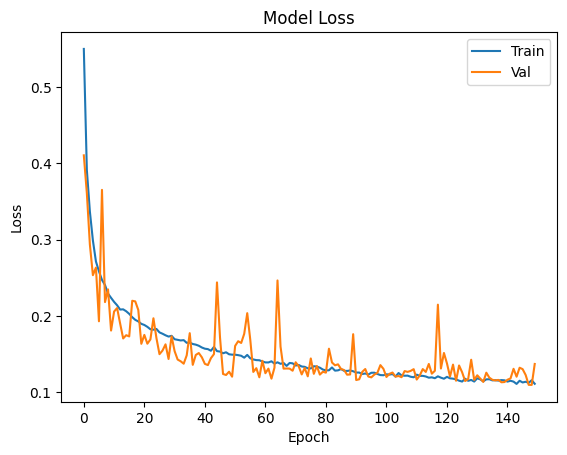

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

 Classification Report:
                  precision    recall  f1-score   support

          Benign       0.94      0.97      0.96      3906
       DDoS-only       0.98      0.97      0.98      4073
      Fraud-only       0.97      0.92      0.94      3996
Fraud-under-DDoS       0.95      0.98      0.96      4025

        accuracy                           0.96     16000
       macro avg       0.96      0.96      0.96     16000
    weighted avg       0.96      0.96      0.96     16000



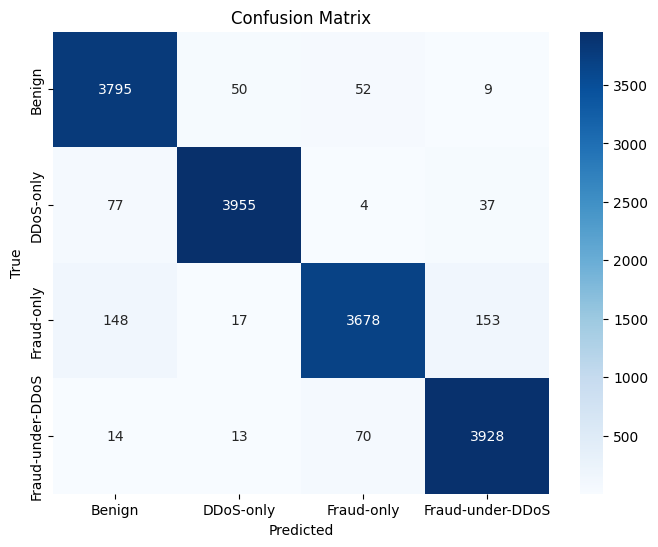

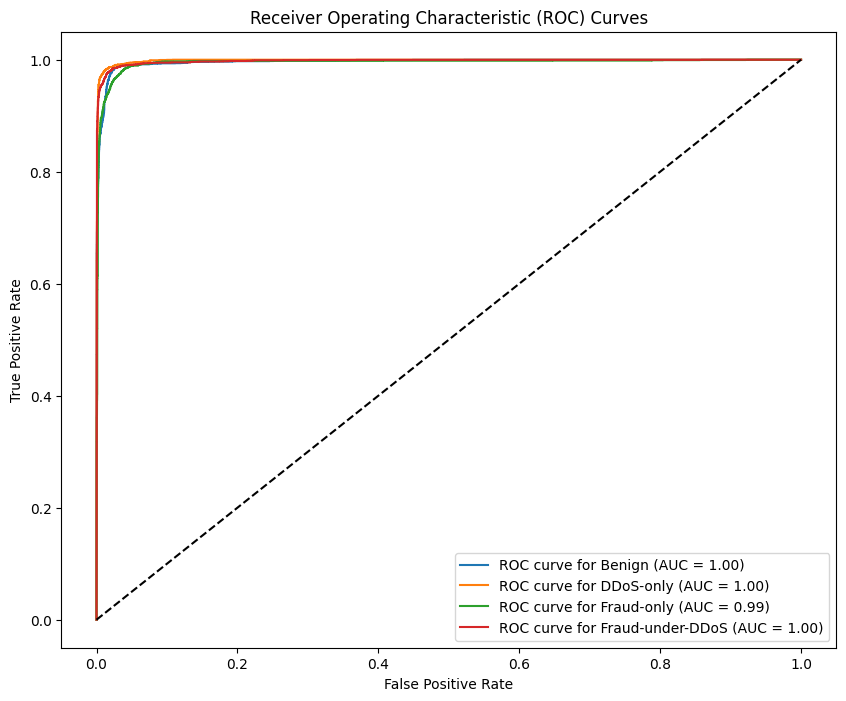


 AUC Score (OvR): 0.9968


In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper right')
plt.show()
target_names = [str(c) for c in le.classes_]

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)


print("\n Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))


cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

plt.figure(figsize=(10, 8))
for i in range(len(target_names)):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
    plt.plot(fpr, tpr, label=f'ROC curve for {target_names[i]} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.show()

try:
    auc_score = roc_auc_score(y_test, y_pred_probs, multi_class="ovr")
    print(f"\n AUC Score (OvR): {auc_score:.4f}")
except Exception as e:
    print(" Could not compute AUC:", e)


# Step 8: Implementation of Proposed CADE-GF

## Step 8 (a): Attacker Utility Function

In [ ]:
def attacker_utility(prob_fraud, threshold=0.5, cost_detected=1.0, reward_evade=5.0, cost_false_positive=0.5):
    if prob_fraud >= threshold:
        return -cost_detected * prob_fraud
    else:
        return reward_evade * (1 - prob_fraud) - cost_false_positive * prob_fraud

## Step 8 (b): Threshold Search Resolution Function

In [ ]:
def optimal_threshold(pred_probs, true_labels):
    thresholds = np.linspace(0.1, 0.9, 81)
    best_thresh = 0.5
    min_utility = float('inf')

    for t in thresholds:
        evasion_utilities = [
            attacker_utility(prob, threshold=t, cost_detected=2.0)
            for prob, true in zip(pred_probs, true_labels) if true != 0
        ]
        if evasion_utilities:
            avg_utility = np.mean(evasion_utilities)
            if avg_utility < min_utility:
                min_utility = avg_utility
                best_thresh = t
    return best_thresh

## Step 8 (c): Evasion Attack function

In [ ]:
def simulate_evasion(X, numeric_cols_indices, epsilon=0.1):
    X_evaded = X.copy()
    X_reshaped = X_evaded.reshape(X_evaded.shape[0], X_evaded.shape[2])
    noise = np.random.normal(0, epsilon, size=(X_reshaped.shape[0], len(numeric_cols_indices)))
    X_reshaped[:, numeric_cols_indices] += noise
    X_evaded = X_reshaped.reshape(X_evaded.shape)
    return X_evaded

## Step 9: Evalaution of CADE-GF
### Print Evalaution Metrics (AUC) Before/After

In [ ]:
feature_names = numeric_cols
continuous_traffic_features = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
    'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean',
    'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean',
    'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std',
    'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Bwd IAT Total',
    'Bwd IAT Mean', 'Bwd IAT Std', 'Fwd Header Length', 'Bwd Header Length',
    'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length',
    'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance',
    'Down/Up Ratio', 'Average Packet Size', 'Avg Fwd Segment Size',
    'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Fwd Avg Bytes/Bulk',
    'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk',
    'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Subflow Fwd Packets',
    'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes',
    'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd',
    'min_seg_size_forward', 'Active Mean', 'Active Std', 'Active Max',
    'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min'
]
continuous_features_to_perturb = [f for f in continuous_traffic_features if f in feature_names]
continuous_feature_indices = [feature_names.index(f) for f in continuous_features_to_perturb if f in feature_names]
pred_probs = model.predict(X_test)
fraud_probs = pred_probs[:, 1]
y_true = np.argmax(y_test, axis=1)
opt_thresh = optimal_threshold(fraud_probs, y_true)
print(f"Optimal threshold: {opt_thresh:.3f}")
y_clean = (fraud_probs >= opt_thresh).astype(int)
X_evaded = simulate_evasion(X_test, continuous_feature_indices, epsilon=0.1)
fraud_probs_evaded = model.predict(X_evaded)[:, 1]
y_evaded = (fraud_probs_evaded >= opt_thresh).astype(int)
try:
    auc_clean = roc_auc_score(y_test, model.predict(X_test), multi_class='ovr')
    auc_evade = roc_auc_score(y_test, model.predict(X_evaded), multi_class='ovr')
    print(f"AUC (clean): {auc_clean:.4f}")
    print(f"AUC (evaded): {auc_evade:.4f}")
    print(f"AUC degradation: {auc_clean - auc_evade:.4f}")
    evasion_success = np.mean((y_clean == 1) & (y_evaded == 0))
    print(f"Evasion success rate: {evasion_success:.4f}")
except Exception as e:
    print(f"Evaluation error: {e}")

500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Optimal threshold: 0.100
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
AUC (clean): 0.9968
AUC (evaded): 0.9968
AUC degradation: 0.0000
Evasion success rate: 0.0000
